# DANDI:001936 NWB Tutorial: Reading a rat pair together

This notebook builds on the [single-subject tutorial](dandi_001936_tutorial.ipynb) for the
Olveczky Lab social behavior dataset (Klibaite et al. 2025), published on the DANDI Archive as
[DANDI:001936](https://dandiarchive.org/dandiset/001936).

Every session in this dataset involves **two rats interacting in the same arena**, but each NWB
file only stores **one rat's perspective** (its own pose keypoints), even though both files
share the same 6-camera video and the same body-contact events table. To analyze a session as a
*pair*, you need to load **both rats' NWB files together** and line them up by their shared
session.

This notebook shows the minimal recipe for that: pick a **subject pair** (rat 1 + rat 2) and
their **common session**, load both NWB files, and combine their pose data into paired
visualizations.

**Color convention used throughout:** rat 1 is always **blue**, rat 2 is always **red**.


## Setup

```bash
pip install dandi pynwb remfile h5py ndx-pose matplotlib pandas opencv-python-headless
```


In [1]:
# Core data manipulation and analysis
from pathlib import Path

import h5py

# Visualization
import matplotlib.pyplot as plt
import numpy as np
import remfile
from dandi.dandiapi import DandiAPIClient

# NWB and DANDI access
from pynwb import NWBHDF5IO
from pynwb.image import ImageSeries

# Configure matplotlib
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# ndx-pose register the extension types used by this dataset with pynwb
# on import -- they don't need to be called directly, just imported.
import ndx_pose  # noqa: F401

# Rat 1 = blue, Rat 2 = red -- used consistently in every plot below.
RAT_COLORS = {1: "blue", 2: "red"}

## Data Access Functions

Same loaders as the single-subject tutorial -- each one loads *one* rat's NWB file, given
its `subject_id`. We'll call each loader twice, once per rat, sharing the same `session_id`.

## 1. Stream a session directly from DANDI

DANDI assets can be read directly over HTTP with [`remfile`](https://github.com/flatironinstitute/remfile),
without downloading the file to disk.


In [2]:
def load_nwb_from_dandi(dandiset_id, subject_id, session_id, modality):
    """
    Load NWB file from DANDI Archive via streaming.
    """
    pattern = f"sub-{subject_id}/sub-{subject_id}_ses-{session_id}_{modality}*.nwb"

    client = DandiAPIClient()
    client.dandi_authenticate()
    dandiset = client.get_dandiset(dandiset_id, "draft")
    assets = dandiset.get_assets_by_glob(pattern=pattern, order="path")

    s3_urls = []
    for asset in assets:
        s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)
        s3_urls.append(s3_url)

    if len(s3_urls) != 1:
        raise ValueError(f"Expected 1 file, found {len(s3_urls)} for pattern {pattern}")

    s3_url = s3_urls[0]

    file = remfile.File(s3_url)
    h5_file = h5py.File(file, "r")
    io = NWBHDF5IO(file=h5_file, load_namespaces=True)
    nwbfile = io.read()

    # Videos in NWB are stored as ImageSeries with external_file containing relative paths
    # We resolve them to full DANDI asset paths and get S3 URLs for streaming

    nwb_parent = Path(asset.path).parent
    video_s3_urls = {}

    for name, obj in nwbfile.acquisition.items():
        # Check for ImageSeries with external_file (videos stored externally)
        if isinstance(obj, ImageSeries) and obj.external_file is not None:
            # Get the relative path and resolve to full DANDI path
            relative_path = obj.external_file[0]
            full_path = f"{nwb_parent}/{relative_path}"

            # Fetch the video asset and get its S3 URL. Keep the query string (strip_query=False):
            # while the dandiset is in draft, the blob store requires the signed URL it carries --
            # a stripped URL returns 403 (both for direct HTTP access and for cv2.VideoCapture).
            video_asset = dandiset.get_asset_by_path(full_path)
            if video_asset is not None:
                video_s3_urls[name] = video_asset.get_content_url(
                    follow_redirects=1, strip_query=False
                )

    return nwbfile, io, video_s3_urls

## 2. Read a local NWB file

If the files are already on disk (e.g. mounted from the lab's data share), reading them is
just a standard `NWBHDF5IO` call.

In [3]:
def load_nwb_local(directory_path, subject_id, session_id, modality):
    """
    Load NWB file from local directory.
    """
    directory_path = Path(directory_path)
    nwbfile_path = directory_path / f"sub-{subject_id}_ses-{session_id}_{modality}.nwb"

    if not nwbfile_path.exists():
        raise FileNotFoundError(f"NWB file not found: {nwbfile_path}")

    io = NWBHDF5IO(path=nwbfile_path, load_namespaces=True)
    nwbfile = io.read()

    video_file_paths = {}
    for name, obj in nwbfile.acquisition.items():
        # Check for ImageSeries with external_file (videos stored externally)
        if isinstance(obj, ImageSeries) and obj.external_file is not None:
            video_file_paths[name] = str(directory_path / obj.external_file[0])
    return nwbfile, io, video_file_paths

## 3. Choose a subject pair + their common session

A session pairs two rats together (e.g. session folder `2022_09_22_M1_M2`), but each rat gets
its **own** `subject_id` (e.g. `"ARID1B-M1"` and `"ARID1B-M2"`) and its **own** NWB file. Both
files share the same `session_id`, so that's the key that ties them together.

Set `subject_id_rat1` / `subject_id_rat2` and the shared `session_id` below -- everything after
this cell loads and plots both rats together.

In [4]:
# Choose data source (DANDI streaming or local)
USE_DANDI = True  # Set to False to use local files
dandiset_id = "001936"

# The subject pair for this session -- rat 1 is blue, rat 2 is red throughout this notebook.
subject_id_rat1 = "ARID1B-M1"
subject_id_rat2 = "ARID1B-M2"
session_id = "day-1-social-M1-M2-20221017"  # shared by both rats
modality = "image"

nwbfiles, ios, video_paths = {}, {}, {}
for rat_idx, subject_id in [(1, subject_id_rat1), (2, subject_id_rat2)]:
    if USE_DANDI:
        nwbfile, io, paths = load_nwb_from_dandi(dandiset_id, subject_id, session_id, modality)
    else:
        # Specify your local directory path
        local_directory = f"H:/{dandiset_id}/sub-{subject_id}"  # Replace with actual path
        nwbfile, io, paths = load_nwb_local(local_directory, subject_id, session_id, modality)
    nwbfiles[rat_idx], ios[rat_idx], video_paths[rat_idx] = nwbfile, io, paths

# Sanity check: both files should describe the same session
assert nwbfiles[1].session_start_time == nwbfiles[2].session_start_time, "session_start_time mismatch between the two rats' files"
print("Both files loaded for session:", session_id)
print("Session start time:", nwbfiles[1].session_start_time)

Both files loaded for session: day-1-social-M1-M2-20221017
Session start time: 2022-10-17 00:00:00+00:00


## 4. Subject metadata, side by side

In [5]:
for rat_idx, nwbfile in nwbfiles.items():
    subject = nwbfile.subject
    print(f"Rat {rat_idx} ({RAT_COLORS[rat_idx]}) -- {subject.subject_id}")
    print("  Strain:      ", subject.strain)
    print("  Genotype:    ", subject.genotype)
    print("  Sex:         ", subject.sex)
    print("  Date of birth:", subject.date_of_birth)
    print("  Description: ", subject.description)
    print()

Rat 1 (blue) -- ARID1B-M1
  Strain:       LE-Arid1b-em1Mcwi
  Genotype:     KO wt
  Sex:          U
  Date of birth: 2022-06-16 00:00:00+00:00
  Description:  Rat M1 from cohort ARID1B. Marking: LB. Cage: 2. Mother: LEF0537. Supplier: Medical College of Wisconsin. RRID: RGD_14394518

Rat 2 (red) -- ARID1B-M2
  Strain:       LE-Arid1b-em1Mcwi
  Genotype:     KO Het
  Sex:          U
  Date of birth: 2022-06-16 00:00:00+00:00
  Description:  Rat M2 from cohort ARID1B. Marking: LM. Cage: 1. Mother: unknown. Supplier: Medical College of Wisconsin. RRID: RGD_14394518



## 5. Paired pose trajectories

Both rats' `PoseEstimationSDANNCE` are on the same clock (`starting_time` + `rate`), so their
keypoint trajectories can be overlaid directly -- no additional alignment needed.

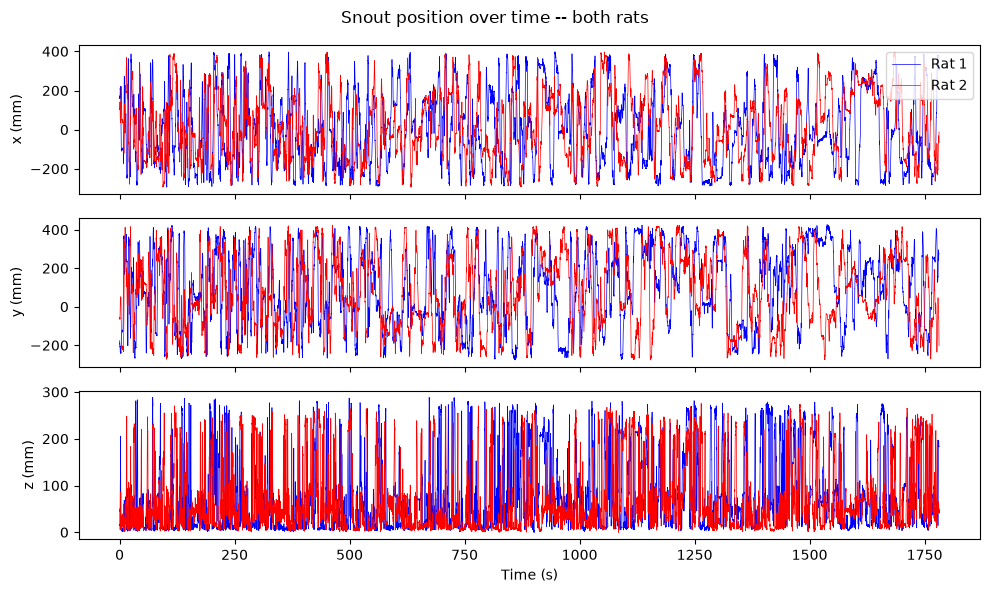

In [6]:
snout_xyz = {}
t = {}
for rat_idx, nwbfile in nwbfiles.items():
    pose_estimation = nwbfile.processing["behavior"]["PoseEstimationSDANNCE"]
    snout = pose_estimation.pose_estimation_series["PoseEstimationSeriesSnout"]
    snout_xyz[rat_idx] = snout.data[:]
    t[rat_idx] = np.arange(snout_xyz[rat_idx].shape[0]) / snout.rate + snout.starting_time

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, dim, label in zip(axes, range(3), ["x", "y", "z"]):
    for rat_idx in (1, 2):
        ax.plot(t[rat_idx], snout_xyz[rat_idx][:, dim], linewidth=0.5, color=RAT_COLORS[rat_idx], label=f"Rat {rat_idx}")
    ax.set_ylabel(f"{label} (mm)")
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Snout position over time -- both rats")
fig.tight_layout()

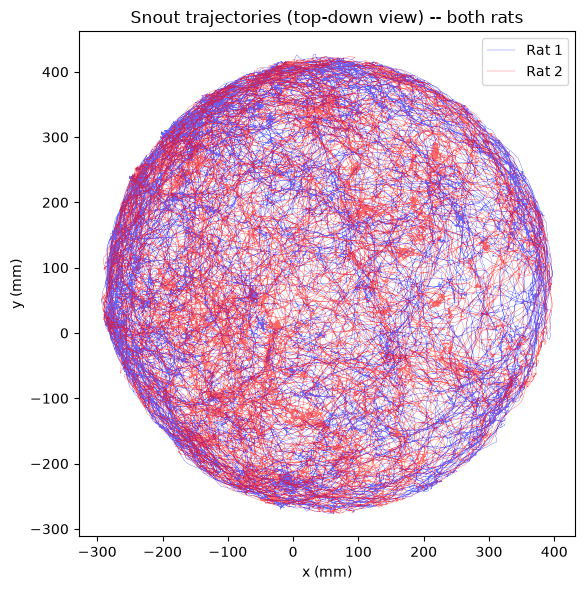

In [7]:
# Top-down (x, y) trajectories for both rats
fig, ax = plt.subplots(figsize=(6, 6))
for rat_idx in (1, 2):
    ax.plot(snout_xyz[rat_idx][:, 0], snout_xyz[rat_idx][:, 1], linewidth=0.3, alpha=0.6, color=RAT_COLORS[rat_idx], label=f"Rat {rat_idx}")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_aspect("equal")
ax.set_title("Snout trajectories (top-down view) -- both rats")
ax.legend()
fig.tight_layout()

## 6. Both rats' skeletons at a single frame

Each rat's file has its own `Skeletons` container describing that rat's keypoint graph (nodes +
edges). Since a file only ever holds one rat, we just take its single skeleton entry.

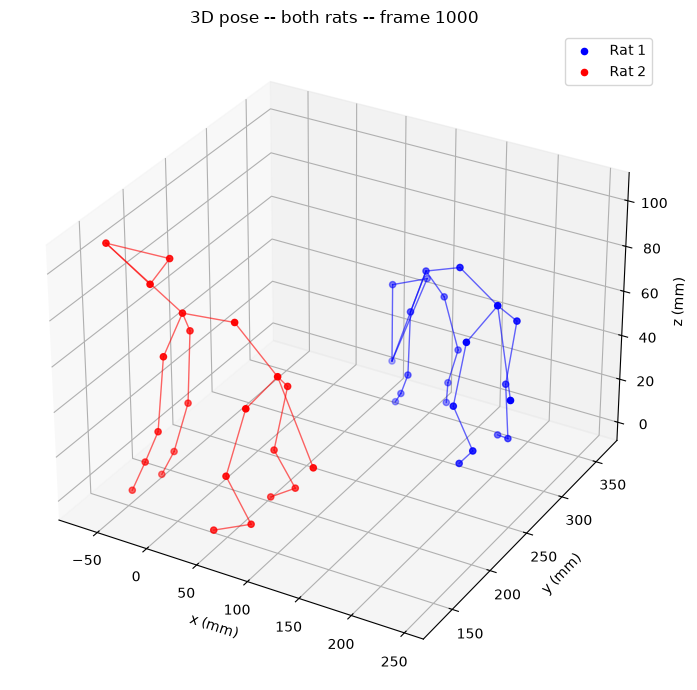

In [8]:
frame_idx = 1000

skeletons = {}
coords = {}
for rat_idx, nwbfile in nwbfiles.items():
    skeleton = next(iter(nwbfile.processing["behavior"]["Skeletons"].skeletons.values()))
    nodes = skeleton.nodes[:]
    edges = skeleton.edges[:]
    pose_estimation = nwbfile.processing["behavior"]["PoseEstimationSDANNCE"]
    coords[rat_idx] = np.array(
        [pose_estimation.pose_estimation_series[f"PoseEstimationSeries{node.capitalize()}"].data[frame_idx]
         for node in nodes]
    )
    skeletons[rat_idx] = {"nodes": nodes, "edges": edges}

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection="3d")
for rat_idx in (1, 2):
    xyz = coords[rat_idx]
    color = RAT_COLORS[rat_idx]
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=color, s=20, label=f"Rat {rat_idx}")
    for node_i, node_j in skeletons[rat_idx]["edges"]:
        xs, ys, zs = xyz[[node_i, node_j]].T
        ax.plot(xs, ys, zs, color=color, linewidth=1, alpha=0.6)

ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("z (mm)")
ax.set_title(f"3D pose -- both rats -- frame {frame_idx}")
ax.legend()
fig.tight_layout()

## 7. Both rats' poses overlaid on a video frame

Both rats' NWB files link to the *same* external video files and the *same* per-camera
calibration (`ndx_pose.CalibratedCamera`), so we only need one file's camera device to project
either rat's 3D keypoints into 2D pixel space.

In [9]:
def project_points(points_3d, camera):
    """Project (n, 3) world-space points (mm) into a CalibratedCamera's 2D pixel coordinates.

    DANNCE calibration matrices are stored in MATLAB's row-vector convention
    (``x_cam = x_world @ r + t``, ``x_pixel ~ x_cam @ K``), which is the transpose of the
    column-vector convention OpenCV's `cv2.projectPoints` expects -- hence transposing
    `rotation_matrix`/`intrinsic_matrix` below.
    """
    import cv2

    rotation_vector, _ = cv2.Rodrigues(np.asarray(camera.rotation_matrix).T)
    translation_vector = np.asarray(camera.translation_vector)
    intrinsic_matrix = np.asarray(camera.intrinsic_matrix).T
    distortion_coefficients = (
        np.asarray(camera.distortion_coefficients) if camera.distortion_coefficients is not None else None
    )
    points_2d, _ = cv2.projectPoints(
        points_3d, rotation_vector, translation_vector, intrinsic_matrix, distortion_coefficients
    )
    return points_2d.reshape(-1, 2)

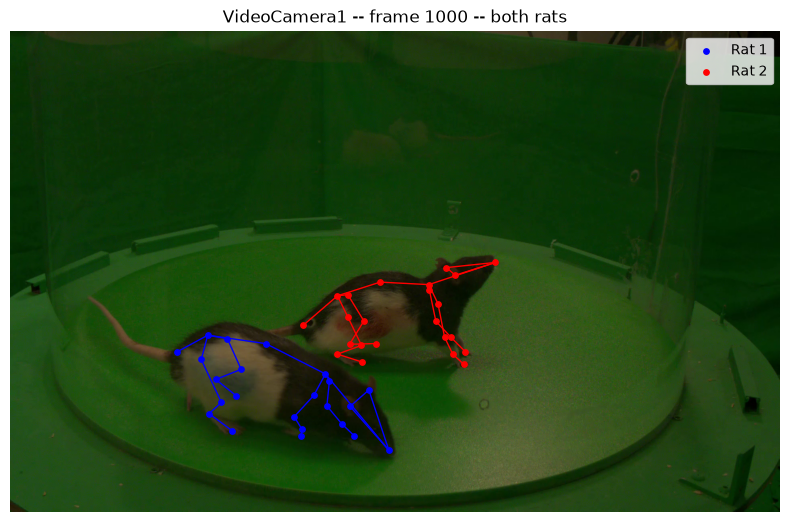

In [10]:
import cv2

camera_to_display = "VideoCamera1"

# Video + calibration are identical between the two rats' files -- read them from rat 1's file.
video_source = video_paths[1][camera_to_display]
camera_device = nwbfiles[1].acquisition[camera_to_display].device

cap = cv2.VideoCapture(video_source)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)  # frame_idx set in section 6, kept in sync with `coords`
success, frame = cap.read()
cap.release()

if success:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    for rat_idx in (1, 2):
        points_2d = project_points(coords[rat_idx], camera_device)
        color = RAT_COLORS[rat_idx]
        for node_i, node_j in skeletons[rat_idx]["edges"]:
            xs, ys = points_2d[[node_i, node_j]].T
            ax.plot(xs, ys, color=color, linewidth=1)
        ax.scatter(points_2d[:, 0], points_2d[:, 1], color=color, s=15, zorder=3, label=f"Rat {rat_idx}")
    ax.set_title(f"{camera_to_display} -- frame {frame_idx} -- both rats")
    ax.legend()
    ax.axis("off")
    fig.tight_layout()
else:
    print(f"Could not read frame {frame_idx} from {camera_to_display} ({video_source})")

## 8. Body-contact events between the two rats

`events/SkinContacts` is written once per session and referenced identically from both rats'
NWB files, so reading it from either file gives the same table -- we just read it from rat 1's
file here.

In [11]:
skin_contacts = nwbfiles[1].events["SkinContacts"]
contacts_df = skin_contacts.to_dataframe()
contacts_df.head()

,timestamp,event_type,frame_index,rat1_vertex,rat2_vertex
id,,,,,
0,0.0,right finger x right foot,0,1610,185
1,0.0,right finger x right foot,0,1613,185
2,0.0,right finger x right foot,0,1614,189
3,0.0,right finger x right foot,0,1615,185
4,0.0,right finger x right foot,0,1625,189


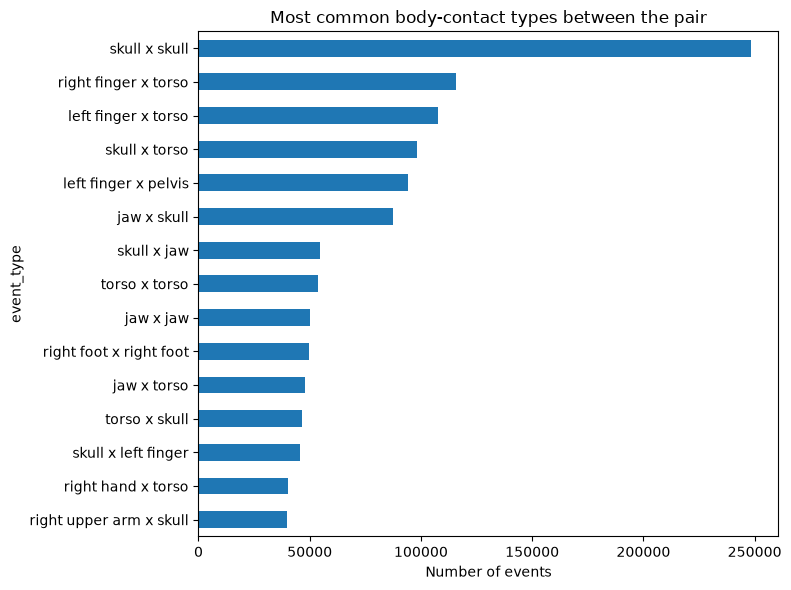

In [12]:
top_contacts = contacts_df["event_type"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_contacts.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Number of events")
ax.set_title("Most common body-contact types between the pair")
fig.tight_layout()

## Summary

This notebook showed how to:

- Pick a subject pair (rat 1 / rat 2) and their shared `session_id`, and load both rats' NWB
  files together (streaming from DANDI or from local files)
- Keep a consistent color convention (rat 1 = blue, rat 2 = red) across every plot
- Overlay both rats' pose trajectories and full 3D skeletons on the same axes
- Project both rats' 3D keypoints into a shared camera's 2D pixel space and draw them together
  on one video frame
- Read the shared body-contact events table, which links the two rats' interactions

For a deeper single-rat walkthrough of the file structure (acquisition, processing modules,
events), see the [single-subject tutorial](dandi_001936_tutorial.ipynb).

### Further resources

- [PyNWB documentation](https://pynwb.readthedocs.io/)
- [NWB overview](https://www.nwb.org/)
- [DANDI Archive documentation](https://www.dandiarchive.org/handbook/)
- [ndx-pose extension](https://github.com/rly/ndx-pose)
- [ndx-events extension](https://github.com/rly/ndx-events)